In [2]:
header = "D:/K_sunada/database/"

## ac stark shift

result

analyze

In [33]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [4]:
ac = "/2023-07-18/2023-07-18T161533_e2d33cfb-td_fogi_ac_Stark_shift"
dd_ac = datadict_from_hdf5(header + ac +"/data")

xs = []
ys = []

for i in range(11):
    ini = 101*i
    fin = 101*(1+i)
    x = dd_ac['fogi_freq']['values'][ini:fin]
    y = dd_ac['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)

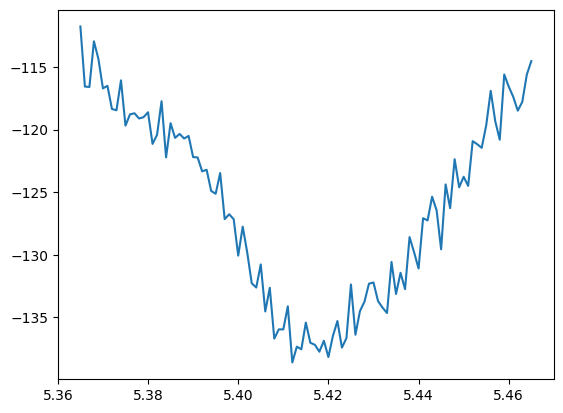

In [5]:
plt.plot(xs[0], ys[0])
plt.show()

In [6]:
par_ini = {
    'amp': 30,
    'const':-115,
    'center':5.415,
    'k':0.025
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [7]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [8]:
results = []
for i in range(10):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

In [18]:
results[9]

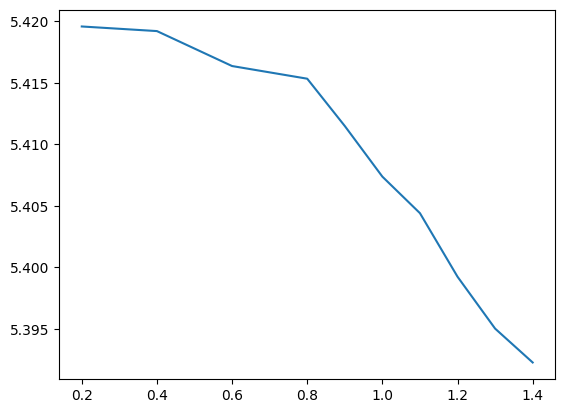

In [19]:
x =[0.2, 0.4, 0.6 , 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]
y =[5.41958018, 5.41920569, 5.41636511, 5.41533600, 5.41149098, 5.40737740, 5.40440774, 5.39924413, 5.39502867, 5.39227489	] #[6.41555167, 6.48026938	, 6.49027817, 6.48438702, 6.48341941, 6.48623481, 6.48469270, 6.48116290, 6.48128617, 6.47848298]

plt.plot(x, y)
plt.show()

In [20]:
def ac_stark(amp, const, alpha):
    return const - alpha*(amp**2)

In [25]:
par_ini = {
    'const':5.42,
    'alpha':0.015
}

par_min = {
    'const':0,
    'alpha':0
}

par_max = {
    'const':np.inf,
    'alpha':np.inf
}

par_vary = {
    'const':True,
    'alpha':True
}

In [26]:
model = lmfit.Model(ac_stark)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [27]:
result = model.fit(data = y, params=params, amp = x)
result

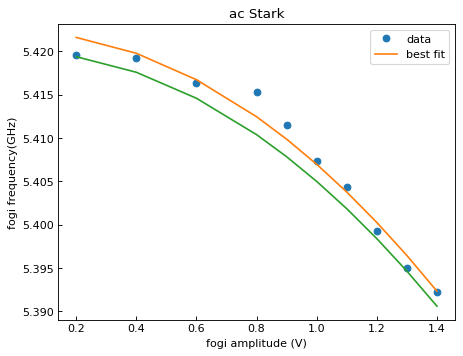

In [28]:
fig, ax = plt.subplots(dpi=80)

plt.title("ac Stark")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(x ,result.init_fit)

plt.xlabel("fogi amplitude (V)")
plt.ylabel("fogi frequency(GHz)")


plt.show()

## fogi freq